In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Load
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values=["?", ""],
    low_memory=False
)

# Basic structure
print(df.shape)
print(df.head())
print(df.info())

# Column names
print(df.columns.tolist())

# Data quality
print(df.isnull().sum())          # missing values
print(df.duplicated().sum())      # duplicates

# Summary stats
print(df.describe())

(2075259, 9)
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data c

In [5]:
# Combine Date + Time into one datetime column
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],
                                format="%d/%m/%Y %H:%M:%S")

# Convert measurement columns to numbers
num_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
            "Global_intensity", "Sub_metering_1", "Sub_metering_2",
            "Sub_metering_3"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

Distributions

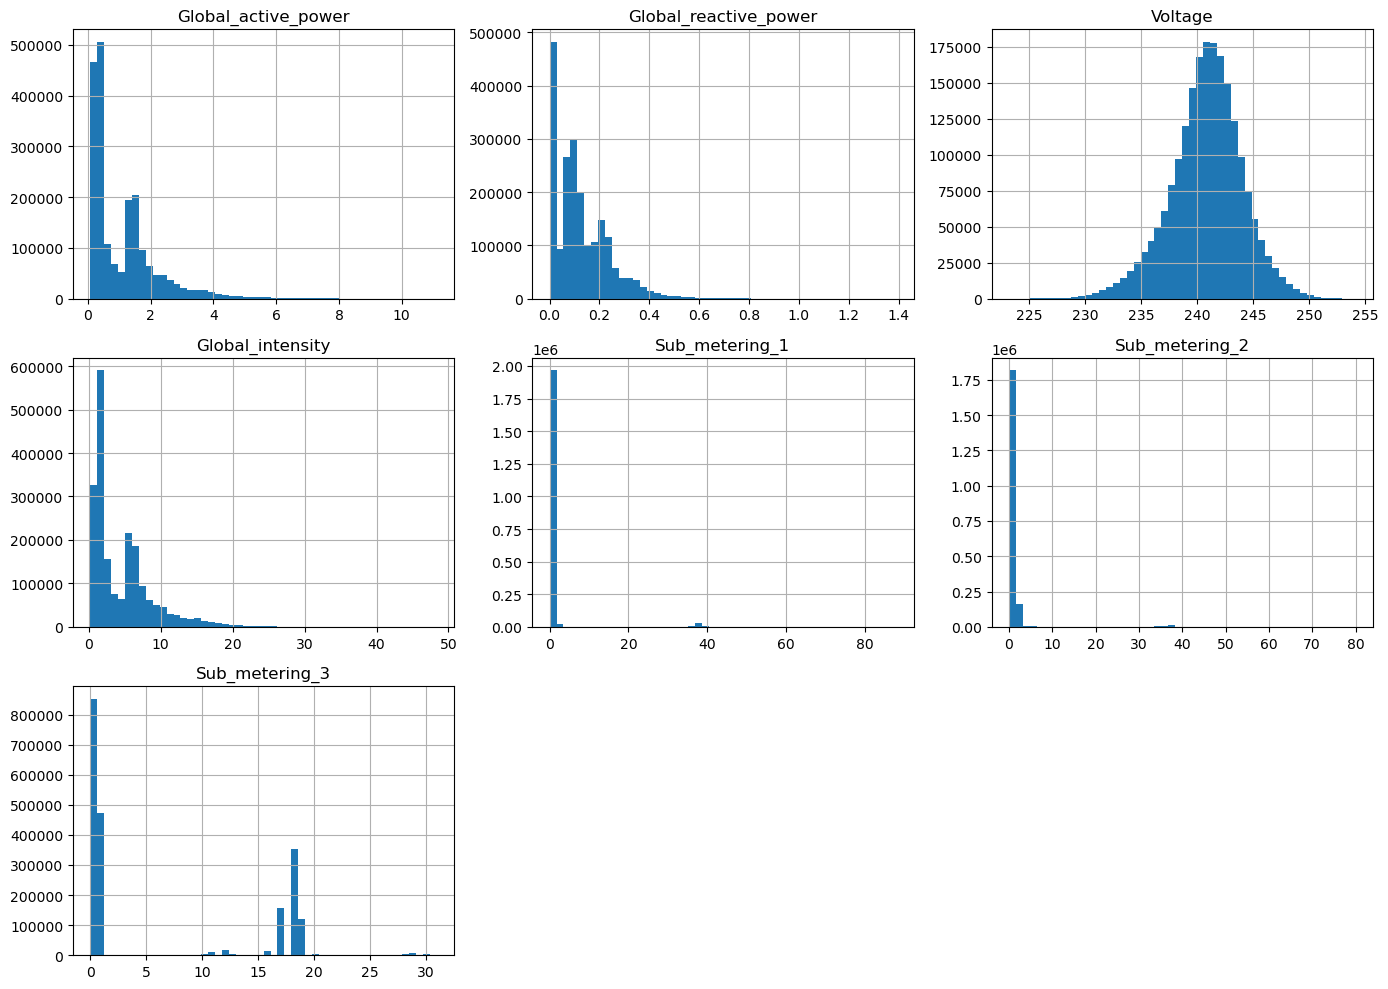

In [8]:
df[num_cols].hist(bins=50, figsize=(14, 10))
plt.tight_layout()
plt.show()

Outliers (boxplots)

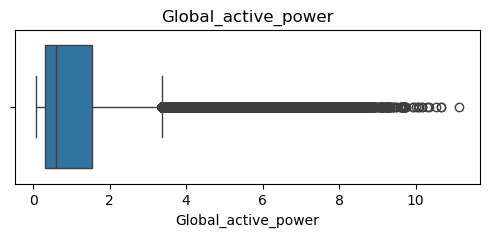

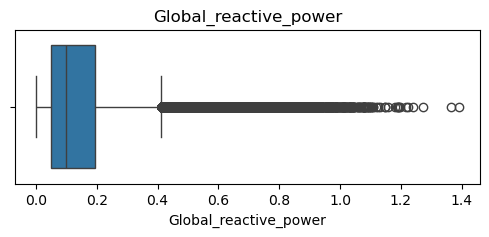

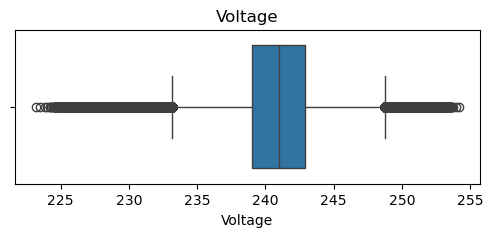

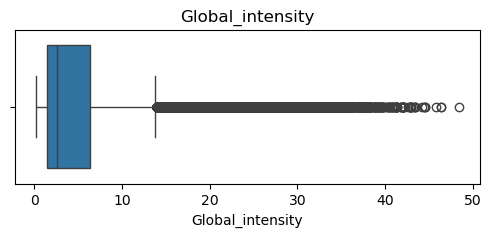

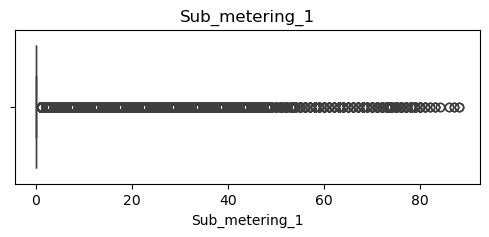

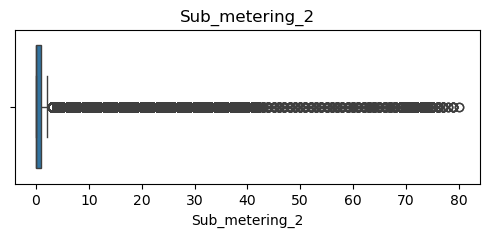

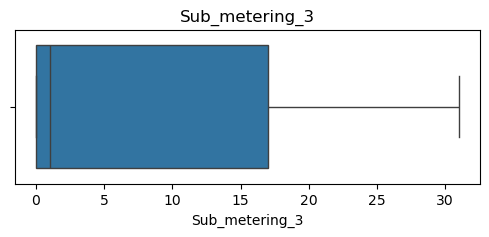

In [11]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Correlation

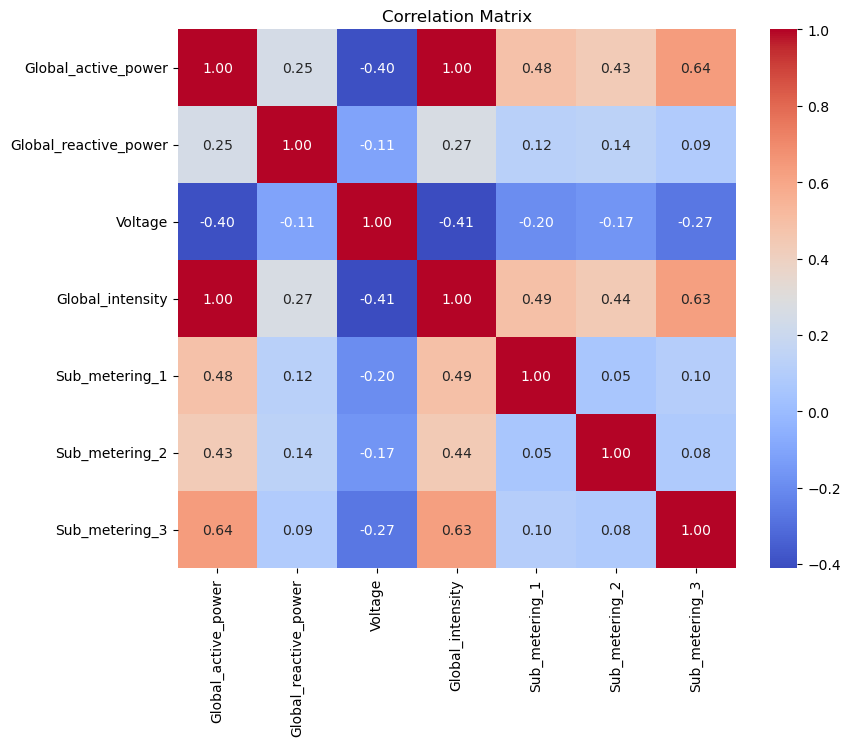

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [16]:
df = df.drop(columns=["Global_intensity"])

print(df.columns.tolist())
print(df.shape) #dropping it because of leakage

['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime']
(2075259, 9)


Time patterns

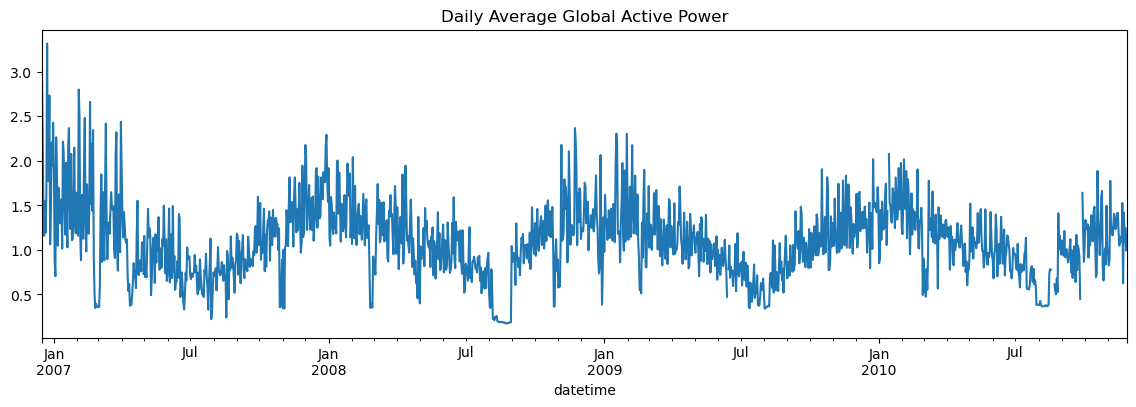

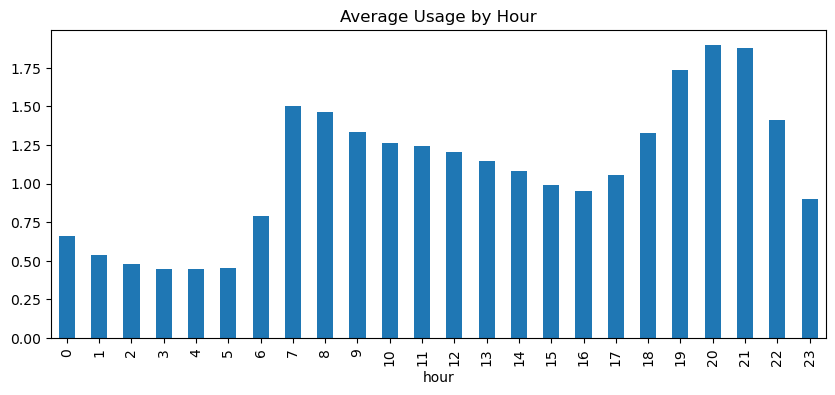

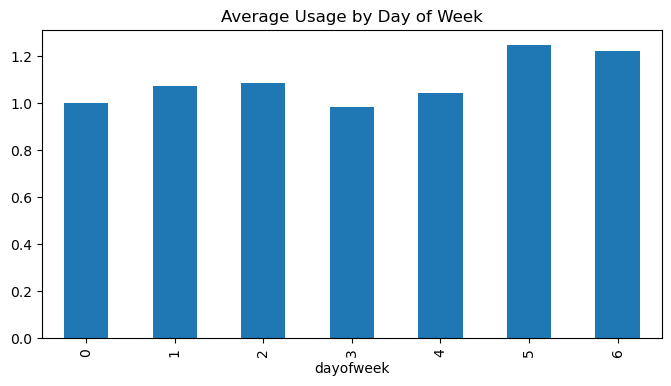

In [19]:
daily = df.set_index("datetime")["Global_active_power"].resample("D").mean()
daily.plot(figsize=(14, 4), title="Daily Average Global Active Power")
plt.show()

# Hourly pattern
df["hour"] = df["datetime"].dt.hour
df.groupby("hour")["Global_active_power"].mean().plot(
    kind="bar", figsize=(10, 4), title="Average Usage by Hour")
plt.show()

# Weekday pattern
df["dayofweek"] = df["datetime"].dt.dayofweek
df.groupby("dayofweek")["Global_active_power"].mean().plot(
    kind="bar", figsize=(8, 4), title="Average Usage by Day of Week")
plt.show()

DATA PREPROCESSING

Handle missing / inconsistent data

In [23]:
print("Missing rows %:", round(df["Global_active_power"].isnull().mean() * 100, 2))
print(df.isnull().sum())

Missing rows %: 1.25
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
hour                         0
dayofweek                    0
dtype: int64


In [25]:
# 2. Drop missing rows (only 1.25%)
df = df.dropna().reset_index(drop=True)

In [27]:
# 3. Inconsistency checks
num_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
            "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

print("Negative values:\n", (df[num_cols] < 0).sum())
print("Voltage out of range:", df[(df["Voltage"] < 200) | (df["Voltage"] > 260)].shape[0])
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

Negative values:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
Voltage out of range: 0
Duplicate timestamps: 0


In [29]:
# 4. Remove impossible / duplicate rows
df = df[df["Global_active_power"] >= 0]
df = df.drop_duplicates(subset="datetime").reset_index(drop=True)

In [31]:
# 5. Confirm
print("Final shape:", df.shape)
print("Nulls left:", df.isnull().sum().sum())

Final shape: (2049280, 11)
Nulls left: 0


Parsing Date and Time

In [33]:
# ---------- Time feature engineering ----------

df["year"]       = df["datetime"].dt.year
df["month"]      = df["datetime"].dt.month
df["day"]        = df["datetime"].dt.day
df["hour"]       = df["datetime"].dt.hour
df["minute"]     = df["datetime"].dt.minute
df["dayofweek"]  = df["datetime"].dt.dayofweek     # 0 = Monday, 6 = Sunday
df["weekofyear"] = df["datetime"].dt.isocalendar().week.astype(int)

# Binary flag
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Season (France)
def get_season(m):
    if m in [12, 1, 2]:
        return 0   # Winter
    elif m in [3, 4, 5]:
        return 1   # Spring
    elif m in [6, 7, 8]:
        return 2   # Summer
    else:
        return 3   # Autumn

df["season"] = df["month"].apply(get_season)

# Drop the original text columns
df = df.drop(columns=["Date", "Time"])

print(df.columns.tolist())
print(df.head())

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime', 'hour', 'dayofweek', 'year', 'month', 'day', 'minute', 'weekofyear', 'is_weekend', 'season']
   Global_active_power  Global_reactive_power  Voltage  Sub_metering_1  \
0                4.216                  0.418   234.84             0.0   
1                5.360                  0.436   233.63             0.0   
2                5.374                  0.498   233.29             0.0   
3                5.388                  0.502   233.74             0.0   
4                3.666                  0.528   235.68             0.0   

   Sub_metering_2  Sub_metering_3            datetime  hour  dayofweek  year  \
0             1.0            17.0 2006-12-16 17:24:00    17          5  2006   
1             1.0            16.0 2006-12-16 17:25:00    17          5  2006   
2             2.0            17.0 2006-12-16 17:26:00    17          5  2006   
3             1.

Adding additional features

In [37]:
df = df.sort_values("datetime").reset_index(drop=True)

In [39]:
#lag features 
df["lag_1min"]  = df["Global_active_power"].shift(1)
df["lag_60min"] = df["Global_active_power"].shift(60)      # 1 hour ago
df["lag_1day"]  = df["Global_active_power"].shift(1440)    # same time yesterday

In [41]:
#rolling averages
df["roll_mean_60"]  = df["Global_active_power"].shift(1).rolling(60).mean()    # last hour
df["roll_mean_1440"] = df["Global_active_power"].shift(1).rolling(1440).mean() # last 24 hours
df["roll_std_60"]   = df["Global_active_power"].shift(1).rolling(60).std()

In [43]:
#Daily average
df["date"] = df["datetime"].dt.date
daily_avg = df.groupby("date")["Global_active_power"].mean().shift(1)   # previous day's avg
df["prev_day_avg"] = df["date"].map(daily_avg)
df = df.drop(columns=["date"])

In [45]:
#peak hour

# Evening peak (18:00–21:00) based on hourly EDA plot
df["is_peak_hour"] = df["hour"].between(18, 21).astype(int)

In [47]:
#Drop rows with NaN created by lags
df = df.dropna().reset_index(drop=True)
print(df.shape)
print(df.columns.tolist())

(2047840, 24)
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'datetime', 'hour', 'dayofweek', 'year', 'month', 'day', 'minute', 'weekofyear', 'is_weekend', 'season', 'lag_1min', 'lag_60min', 'lag_1day', 'roll_mean_60', 'roll_mean_1440', 'roll_std_60', 'prev_day_avg', 'is_peak_hour']


Featuring Engineering

In [50]:
corr = df.corr(numeric_only=True)["Global_active_power"].sort_values(ascending=False)
print(corr)

Global_active_power      1.000000
lag_1min                 0.968162
roll_mean_60             0.763557
Sub_metering_3           0.638856
roll_std_60              0.573892
lag_60min                0.492922
Sub_metering_1           0.484753
Sub_metering_2           0.434575
lag_1day                 0.325575
roll_mean_1440           0.322094
hour                     0.281767
is_peak_hour             0.261648
Global_reactive_power    0.247327
prev_day_avg             0.239211
is_weekend               0.083316
dayofweek                0.064706
minute                   0.002427
day                      0.001959
year                    -0.032414
weekofyear              -0.034002
month                   -0.034227
season                  -0.126189
Voltage                 -0.399403
Name: Global_active_power, dtype: float64


lag_1min                 0.961604
Sub_metering_1           0.009771
Sub_metering_2           0.007497
Sub_metering_3           0.005266
Voltage                  0.002744
roll_mean_60             0.002615
roll_mean_1440           0.001445
Global_reactive_power    0.001262
roll_std_60              0.001226
lag_60min                0.001026
hour                     0.000920
prev_day_avg             0.000908
lag_1day                 0.000903
minute                   0.000638
day                      0.000495
weekofyear               0.000495
year                     0.000363
season                   0.000259
dayofweek                0.000243
month                    0.000195
is_peak_hour             0.000078
is_weekend               0.000046
dtype: float64


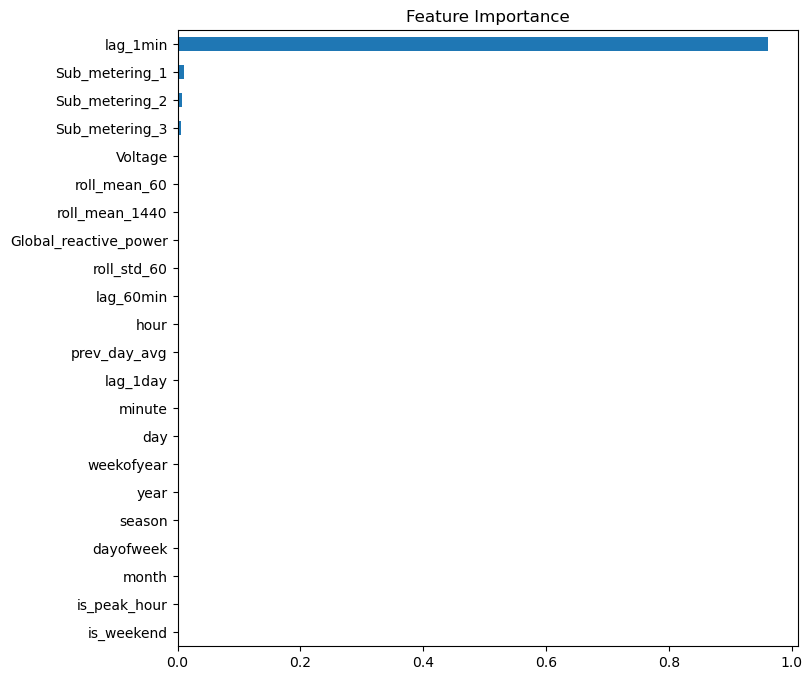

In [52]:
from sklearn.ensemble import RandomForestRegressor
##Feature importance from a quick Random Forest

sample = df.sample(100000, random_state=42)
X_s = sample.drop(columns=["Global_active_power", "datetime"])
y_s = sample["Global_active_power"]

rf = RandomForestRegressor(n_estimators=50, max_depth=12,
                           n_jobs=-1, random_state=42)
rf.fit(X_s, y_s)

imp = pd.Series(rf.feature_importances_, index=X_s.columns).sort_values(ascending=False)
print(imp)

imp.plot(kind="barh", figsize=(8, 8), title="Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [54]:
# selecting top features 
top_features = [
    "lag_1min",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Voltage",
    "roll_mean_60",
    "roll_mean_1440",
    "Global_reactive_power",
    "roll_std_60",
    "lag_60min",
    "hour",
    "prev_day_avg",
    "lag_1day",
    "dayofweek",
    "is_weekend"
]

X = df[top_features]
y = df["Global_active_power"]

print(X.shape)
print(X.columns.tolist())

(2047840, 15)
['lag_1min', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Voltage', 'roll_mean_60', 'roll_mean_1440', 'Global_reactive_power', 'roll_std_60', 'lag_60min', 'hour', 'prev_day_avg', 'lag_1day', 'dayofweek', 'is_weekend']


Model Selection and Training

Train / Test split

In [65]:
from sklearn.model_selection import train_test_split

X = df[top_features]
y = df["Global_active_power"]

# Time-based split: first 80% train, last 20% test
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train period:", df["datetime"].iloc[0], "→", df["datetime"].iloc[split-1])
print("Test period :", df["datetime"].iloc[split], "→", df["datetime"].iloc[-1])

Train: (1638272, 15) Test: (409568, 15)
Train period: 2006-12-17 17:24:00 → 2010-02-05 09:16:00
Test period : 2010-02-05 09:17:00 → 2010-11-26 21:02:00


Model Training

In [68]:
#Model 1: Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE :", round(mean_absolute_error(y_test, y_pred_lr), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4))
print("R2  :", round(r2_score(y_test, y_pred_lr), 4))

Linear Regression
MAE : 0.0943
RMSE: 0.196
R2  : 0.9522


In [70]:
baseline = X_test["lag_1min"]
print("Baseline (lag_1min)")
print("MAE :", round(mean_absolute_error(y_test, baseline), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline)), 4))
print("R2  :", round(r2_score(y_test, baseline), 4))

Baseline (lag_1min)
MAE : 0.0719
RMSE: 0.2216
R2  : 0.9389


In [74]:
import pandas as pd

coef = pd.Series(lr.coef_, index=top_features).sort_values(key=abs, ascending=False)
print(coef)

lag_1min                 0.843755
Sub_metering_1           0.104209
Sub_metering_3           0.093637
Sub_metering_2           0.088533
roll_mean_60             0.067122
Voltage                 -0.031031
roll_mean_1440           0.023394
Global_reactive_power    0.022295
roll_std_60             -0.021464
lag_1day                 0.013627
hour                     0.011779
lag_60min               -0.008770
prev_day_avg             0.007085
is_weekend              -0.003230
dayofweek                0.002414
dtype: float64


In [76]:
#Model 2 : Random Forest :

from sklearn.ensemble import RandomForestRegressor
import time

# Sample the training data for speed
X_train_s = X_train.sample(300000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

start = time.time()
rf.fit(X_train_s, y_train_s)
print("Training time:", round(time.time() - start, 1), "sec")

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("MAE :", round(mean_absolute_error(y_test, y_pred_rf), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))
print("R2  :", round(r2_score(y_test, y_pred_rf), 4))

Training time: 186.9 sec

Random Forest
MAE : 0.0614
RMSE: 0.1624
R2  : 0.9672


lag_1min                 0.955475
Sub_metering_1           0.010278
Sub_metering_2           0.008533
Sub_metering_3           0.005936
Voltage                  0.003687
roll_mean_60             0.003147
roll_std_60              0.002146
roll_mean_1440           0.002056
Global_reactive_power    0.001985
hour                     0.001957
prev_day_avg             0.001481
lag_60min                0.001454
lag_1day                 0.001366
dayofweek                0.000434
is_weekend               0.000067
dtype: float64


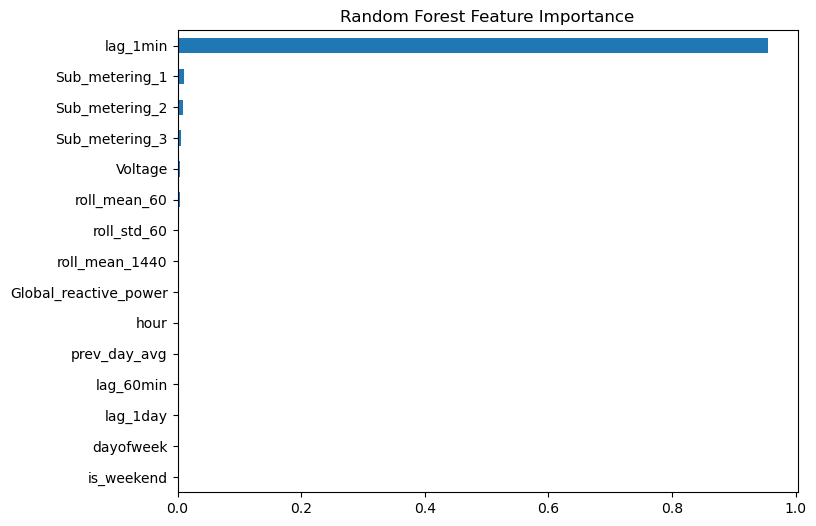

In [78]:
imp_rf = pd.Series(rf.feature_importances_, index=top_features).sort_values(ascending=False)
print(imp_rf)

imp_rf.plot(kind="barh", figsize=(8, 6), title="Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [82]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [80]:
results = {}

results["Baseline"] = {
    "MAE": mean_absolute_error(y_test, baseline),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline)),
    "R2": r2_score(y_test, baseline)
}

results["Linear Regression"] = {
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "R2": r2_score(y_test, y_pred_lr)
}

results["Random Forest"] = {
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "R2": r2_score(y_test, y_pred_rf)
}


print(pd.DataFrame(results).T.round(4))

                      MAE    RMSE      R2
Baseline           0.0719  0.2216  0.9389
Linear Regression  0.0943  0.1960  0.9522
Random Forest      0.0614  0.1624  0.9672


In [84]:
#Model 3 : Gradient Boosting (XGBoost)

from xgboost import XGBRegressor
import time

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

start = time.time()
xgb.fit(X_train, y_train)        # full training set is fine, XGBoost is fast
print("Training time:", round(time.time() - start, 1), "sec")

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost")
print("MAE :", round(mean_absolute_error(y_test, y_pred_xgb), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4))
print("R2  :", round(r2_score(y_test, y_pred_xgb), 4))

results["XGBoost"] = {
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    "R2": r2_score(y_test, y_pred_xgb)
}

print("\n", pd.DataFrame(results).T.round(4))

Training time: 57.0 sec

XGBoost
MAE : 0.0642
RMSE: 0.1534
R2  : 0.9707

                       MAE    RMSE      R2
Baseline           0.0719  0.2216  0.9389
Linear Regression  0.0943  0.1960  0.9522
Random Forest      0.0614  0.1624  0.9672
XGBoost            0.0642  0.1534  0.9707


In [86]:
imp_xgb = pd.Series(xgb.feature_importances_, index=top_features).sort_values(ascending=False)
print(imp_xgb)

lag_1min                 0.682219
roll_mean_60             0.122325
Sub_metering_1           0.064782
Sub_metering_3           0.053083
Sub_metering_2           0.043404
roll_std_60              0.007110
hour                     0.007063
Voltage                  0.005704
Global_reactive_power    0.002637
lag_60min                0.002611
roll_mean_1440           0.002215
prev_day_avg             0.002213
is_weekend               0.001658
dayofweek                0.001549
lag_1day                 0.001427
dtype: float32


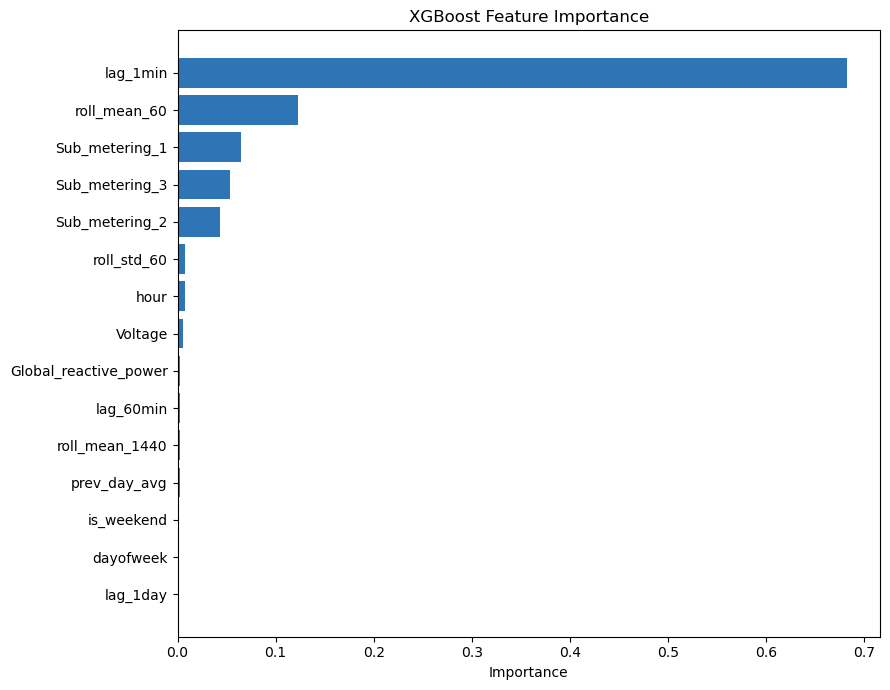

In [130]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

imp_plot = imp_xgb.sort_values(ascending=True)   # largest ends up at top

plt.figure(figsize=(9, 7))
plt.barh(imp_plot.index, imp_plot.values, color="#2E75B6")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [88]:
#Model 4 :Neural Network

from sklearn.neural_network import MLPRegressor
import time

# Sample for speed — MLP is slow on 1.6M rows
X_train_s2 = X_train.sample(300000, random_state=42)
y_train_s2 = y_train.loc[X_train_s2.index]
X_train_s2_scaled = scaler.transform(X_train_s2)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    random_state=42,
    verbose=True
)

start = time.time()
mlp.fit(X_train_s2_scaled, y_train_s2)
print("Training time:", round(time.time() - start, 1), "sec")

y_pred_nn = mlp.predict(X_test_scaled)

print("\nNeural Network")
print("MAE :", round(mean_absolute_error(y_test, y_pred_nn), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_nn)), 4))
print("R2  :", round(r2_score(y_test, y_pred_nn), 4))

results["Neural Network"] = {
    "MAE": mean_absolute_error(y_test, y_pred_nn),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_nn)),
    "R2": r2_score(y_test, y_pred_nn)
}

print("\n", pd.DataFrame(results).T.round(4))

Iteration 1, loss = 0.03820649
Validation score: 0.958769
Iteration 2, loss = 0.02436604
Validation score: 0.959474
Iteration 3, loss = 0.02286497
Validation score: 0.964316
Iteration 4, loss = 0.02198857
Validation score: 0.965026
Iteration 5, loss = 0.02149007
Validation score: 0.965289
Iteration 6, loss = 0.02113507
Validation score: 0.966032
Iteration 7, loss = 0.02088285
Validation score: 0.966874
Iteration 8, loss = 0.02056955
Validation score: 0.966740
Iteration 9, loss = 0.02038298
Validation score: 0.967398
Iteration 10, loss = 0.02016094
Validation score: 0.967627
Iteration 11, loss = 0.02006458
Validation score: 0.966613
Iteration 12, loss = 0.01995747
Validation score: 0.968061
Iteration 13, loss = 0.01980413
Validation score: 0.967727
Iteration 14, loss = 0.01961244
Validation score: 0.968480
Iteration 15, loss = 0.01959861
Validation score: 0.968527
Iteration 16, loss = 0.01946131
Validation score: 0.968421
Iteration 17, loss = 0.01936120
Validation score: 0.968606
Iterat

E:\ANACONDA\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network
MAE : 0.0661
RMSE: 0.1529
R2  : 0.9709

                       MAE    RMSE      R2
Baseline           0.0719  0.2216  0.9389
Linear Regression  0.0943  0.1960  0.9522
Random Forest      0.0614  0.1624  0.9672
XGBoost            0.0642  0.1534  0.9707
Neural Network     0.0661  0.1529  0.9709


Hyperparameter tuning — XGBoost

In [91]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import time

# Sample for tuning speed — keep chronological order, so slice not sample
X_tune = X_train.iloc[-400000:]
y_tune = y_train.iloc[-400000:]

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [6, 8, 10, 12],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10]
}

search = RandomizedSearchCV(
    XGBRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=15,                      # 15 random combos
    cv=TimeSeriesSplit(n_splits=3), # time-aware CV
    scoring="neg_root_mean_squared_error",
    verbose=2,
    random_state=42
)

start = time.time()
search.fit(X_tune, y_tune)
print("Tuning time:", round(time.time() - start, 1), "sec")

print("Best params:", search.best_params_)
print("Best CV RMSE:", round(-search.best_score_, 4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   3.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=10, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  12.3s
[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=10, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  28.0s
[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=10, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  29.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=12, min_child_weight=10, n_estimators=200, subsample=0.7; t

In [97]:
# Tuned XGB Model

xgb_tuned = XGBRegressor(**search.best_params_, n_jobs=-1, random_state=42)
xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)

print("XGBoost Tuned")
print("MAE :", round(mean_absolute_error(y_test, y_pred_tuned), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_tuned)), 4))
print("R2  :", round(r2_score(y_test, y_pred_tuned), 4))

results["XGBoost Tuned"] = {
    "MAE": mean_absolute_error(y_test, y_pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
    "R2": r2_score(y_test, y_pred_tuned)
}

print("\n", pd.DataFrame(results).T.round(4))

XGBoost Tuned
MAE : 0.0617
RMSE: 0.1575
R2  : 0.9691

                       MAE    RMSE      R2
Baseline           0.0719  0.2216  0.9389
Linear Regression  0.0943  0.1960  0.9522
Random Forest      0.0614  0.1624  0.9672
XGBoost            0.0642  0.1534  0.9707
Neural Network     0.0661  0.1529  0.9709
XGBoost Tuned      0.0617  0.1575  0.9691


In [95]:
#saving the Model (best model = Xgb)
import joblib

joblib.dump(xgb, "final_xgb_model.pkl")

# Verify it saved the right one
check = joblib.load("final_xgb_model.pkl")
print("max_depth:", check.get_params()["max_depth"])        
print("learning_rate:", check.get_params()["learning_rate"])  

max_depth: 8
learning_rate: 0.1


Actual vs Predicted 

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# Match predictions back to their timestamps
test_dates = df["datetime"].iloc[split:].reset_index(drop=True)

comp = pd.DataFrame({
    "datetime": test_dates,
    "actual": y_test.values,
    "predicted": y_pred_xgb
})

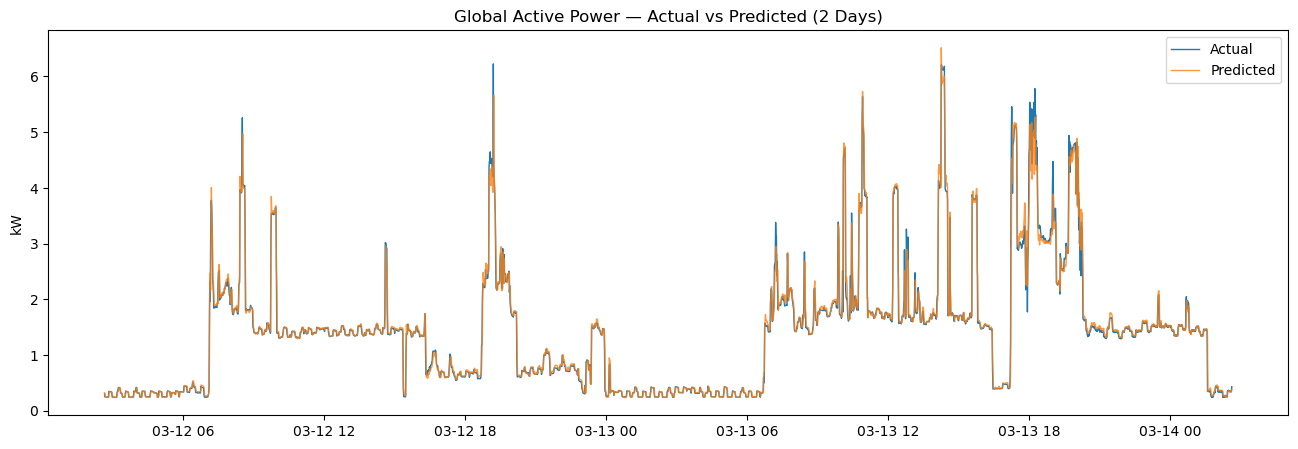

In [102]:
sample = comp.iloc[50000:52880]   # 2 days of minutes

plt.figure(figsize=(16, 5))
plt.plot(sample["datetime"], sample["actual"], label="Actual", linewidth=1)
plt.plot(sample["datetime"], sample["predicted"], label="Predicted", linewidth=1, alpha=0.8)
plt.title("Global Active Power — Actual vs Predicted (2 Days)")
plt.ylabel("kW")
plt.legend()
plt.show()

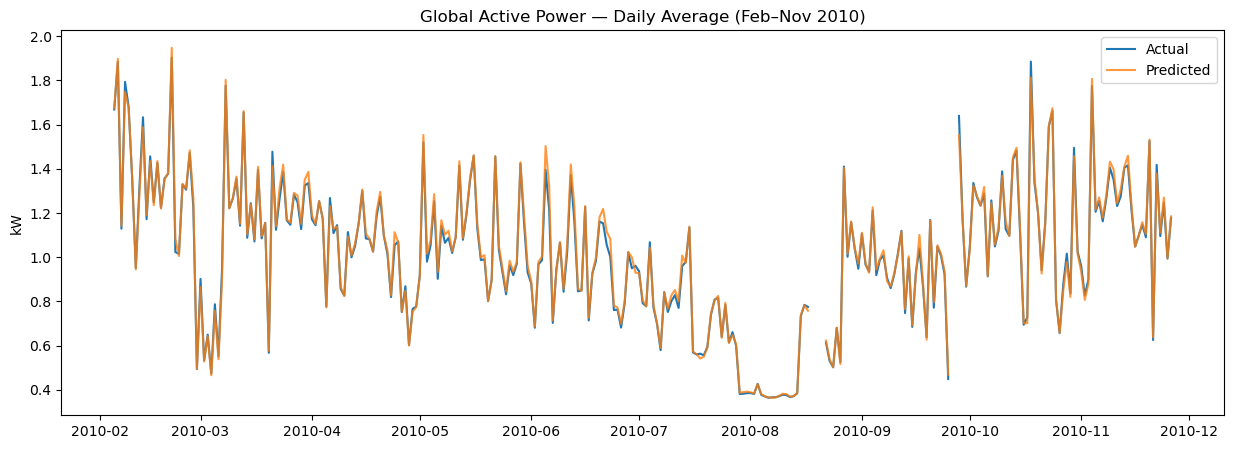

In [104]:
daily = comp.set_index("datetime").resample("D").mean()

plt.figure(figsize=(15, 5))
plt.plot(daily.index, daily["actual"], label="Actual")
plt.plot(daily.index, daily["predicted"], label="Predicted", alpha=0.8)
plt.title("Global Active Power — Daily Average (Feb–Nov 2010)")
plt.ylabel("kW")
plt.legend()
plt.show()

Manual prediction

In [107]:
print(top_features)
print(X_train.describe().T[["mean", "min", "max"]].round(3))

['lag_1min', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Voltage', 'roll_mean_60', 'roll_mean_1440', 'Global_reactive_power', 'roll_std_60', 'lag_60min', 'hour', 'prev_day_avg', 'lag_1day', 'dayofweek', 'is_weekend']
                          mean      min      max
lag_1min                 1.109    0.076   11.122
Sub_metering_1           1.162    0.000   84.000
Sub_metering_2           1.354    0.000   79.000
Sub_metering_3           6.343    0.000   31.000
Voltage                240.727  223.200  254.150
roll_mean_60             1.109    0.120    7.063
roll_mean_1440           1.110    0.172    3.505
Global_reactive_power    0.122    0.000    1.390
roll_std_60              0.411    0.000    2.969
lag_60min                1.109    0.076   11.122
hour                    11.502    0.000   23.000
prev_day_avg             1.111    0.174    3.315
lag_1day                 1.110    0.076   11.122
dayofweek                2.991    0.000    6.000
is_weekend               0.283    0.0

In [109]:
import pandas as pd

sample_input = pd.DataFrame([{
    "lag_1min": 2.5,               # power 1 min ago (kW)
    "Sub_metering_1": 0,           # kitchen (Wh)
    "Sub_metering_2": 1,           # laundry (Wh)
    "Sub_metering_3": 17,          # water heater / AC (Wh)
    "Voltage": 240.0,
    "roll_mean_60": 2.2,           # avg last hour
    "roll_mean_1440": 1.1,         # avg last 24h
    "Global_reactive_power": 0.1,
    "roll_std_60": 0.5,
    "lag_60min": 1.8,              # power 1 hour ago
    "hour": 19,                    # 7 PM
    "prev_day_avg": 1.2,
    "lag_1day": 2.3,               # same time yesterday
    "dayofweek": 2,                # Wednesday
    "is_weekend": 0
}])[top_features]                  # enforce column order

pred = xgb.predict(sample_input)[0]
print("Predicted Global Active Power:", round(pred, 4), "kW")
print("Approx watts:", round(pred * 1000), "W")

Predicted Global Active Power: 2.4994 kW
Approx watts: 2499 W


In [111]:
def predict_power(**kwargs):
    row = pd.DataFrame([kwargs])[top_features]
    return round(float(xgb.predict(row)[0]), 4)

# Example — low usage at 3 AM
print(predict_power(
    lag_1min=0.3, Sub_metering_1=0, Sub_metering_2=0, Sub_metering_3=0,
    Voltage=243.0, roll_mean_60=0.3, roll_mean_1440=1.0,
    Global_reactive_power=0.05, roll_std_60=0.05, lag_60min=0.3,
    hour=3, prev_day_avg=1.1, lag_1day=0.32, dayofweek=2, is_weekend=0
))

0.2837


In [113]:
i = 1000
real_row = X_test.iloc[[i]]
print("Predicted:", round(float(xgb.predict(real_row)[0]), 4))
print("Actual   :", round(y_test.iloc[i], 4))

Predicted: 0.4212
Actual   : 0.424


In [121]:
for i in [500, 1000, 50000, 100000, 200000]:
    p = float(xgb.predict(X_test.iloc[[i]])[0])
    a = y_test.iloc[i]
    print(f"idx {i:>7} | Predicted: {p:.4f} | Actual: {a:.4f} | Error: {abs(p-a):.4f}")

idx     500 | Predicted: 0.4440 | Actual: 0.5260 | Error: 0.0820
idx    1000 | Predicted: 0.4212 | Actual: 0.4240 | Error: 0.0028
idx   50000 | Predicted: 0.3162 | Actual: 0.3160 | Error: 0.0002
idx  100000 | Predicted: 0.3505 | Actual: 0.3480 | Error: 0.0025
idx  200000 | Predicted: 0.2534 | Actual: 0.2580 | Error: 0.0046


In [123]:
import numpy as np
err = np.abs(y_test.values - y_pred_xgb)
worst = err.argsort()[-5:][::-1]

for i in worst:
    print(f"Predicted: {y_pred_xgb[i]:.3f} | Actual: {y_test.iloc[i]:.3f} | Error: {err[i]:.3f}")

Predicted: 1.423 | Actual: 4.428 | Error: 3.005
Predicted: 1.526 | Actual: 4.518 | Error: 2.992
Predicted: 1.263 | Actual: 4.214 | Error: 2.951
Predicted: 1.352 | Actual: 4.260 | Error: 2.908
Predicted: 0.669 | Actual: 3.566 | Error: 2.897


In [132]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(xgb, "models/final_xgb_model.pkl")
joblib.dump(top_features, "models/features.pkl")

['models/features.pkl']